## Importe

In diesem Abschnitt werden die notwendigen Bibliotheken importiert, die für die Datenanalyse und Visualisierung verwendet werden.

In [124]:
import pandas as pd
import numpy as np
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

## Einlesen der CSV-Dateien

In diesem Abschnitt werden die CSV-Dateien eingelesen, die die Gesundheitsindikatoren und Diabetes-Daten enthalten. Diese Daten werden in Pandas DataFrames geladen, um sie für die Analyse und Visualisierung vorzubereiten.

Die folgenden CSV-Dateien werden eingelesen:
- `diabetes_012_health_indicators_BRFSS2015.csv`: Enthält Daten zu verschiedenen Gesundheitsindikatoren und dem Diabetes-Status (0, 1 oder 2).
- `diabetes_binary_health_indicators_BRFSS2015.csv`: Enthält Daten zu verschiedenen Gesundheitsindikatoren und einem binären Diabetes-Status (0 oder 1).
- `diabetes_binary_5050split_health_indicators_BRFSS2015.csv`: Enthält Daten zu verschiedenen Gesundheitsindikatoren und einem binären Diabetes-Status (0 oder 1), wobei die Daten gleichmäßig aufgeteilt sind.

Im weiteren Verlauf des Codes wird nur die `diabetes_012_health_indicators_BRFSS2015.csv` genutzt, da dies der Grunddatensatz ist und die anderen zwei CSV Datein auf diesen aufbauen und die gleichen Daten enthalten.


In [125]:
df_diabetes_012 = pd.read_csv('dataset/diabetes_012_health_indicators_BRFSS2015.csv')
df_diabetes_binary = pd.read_csv('dataset/diabetes_binary_health_indicators_BRFSS2015.csv')
df_diabetes_binary_50_50 = pd.read_csv('dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv')

## Form des Datensatzes `df_diabetes_012`

In diesem Abschnitt wird die Form des Datensatzes `df_diabetes_012` dargestellt. Die Form eines DataFrames gibt die Anzahl der Zeilen und Spalten an und ist ein wichtiger erster Schritt, um ein Gefühl für die Größe und Struktur der Daten zu bekommen.

Die Form des Datensatzes `df_diabetes_012` ist wie folgt:

In [126]:
print(f"Shape df_diabetes_012: {df_diabetes_012.shape}")

Shape df_diabetes_012: (253680, 22)


## Spalten der Datensätze

In diesem Abschnitt werden die Spaltennamen der eingelesenen Datensätze angezeigt. Dies gibt einen Überblick über die verschiedenen Gesundheitsindikatoren und Merkmale, die in den Datensätzen enthalten sind.

### Spaltennamen für alle CSV Dateien mit Skalenniveau und Typ

- **Diabetes_012**: Diabetes-Status (0, 1 oder 2), Ordinal, Output
- **HighBP**: Bluthochdruck (0 oder 1), Nominal (binär), Input
- **HighChol**: Hoher Cholesterinspiegel (0 oder 1), Nominal (binär), Input
- **CholCheck**: Cholesterinüberprüfung (0 oder 1), Nominal (binär), Input
- **BMI**: Body-Mass-Index, Kardinal, Input
- **Smoker**: Raucherstatus (0 oder 1), Nominal (binär), Input
- **Stroke**: Schlaganfall (0 oder 1), Nominal (binär), Input
- **HeartDiseaseorAttack**: Herzkrankheit oder Herzinfarkt (0 oder 1), Nominal (binär), Input
- **PhysActivity**: Körperliche Aktivität (0 oder 1), Nominal (binär), Input
- **Fruits**: Obstkonsum (0 oder 1), Nominal (binär), Input
- **Veggies**: Gemüsekonsum (0 oder 1), Nominal (binär), Input
- **HvyAlcoholConsump**: Hoher Alkoholkonsum (0 oder 1), Nominal (binär), Input
- **AnyHealthcare**: Zugang zu Gesundheitsversorgung (0 oder 1), Nominal (binär), Input
- **NoDocbcCost**: Kein Arztbesuch wegen Kosten (0 oder 1), Nominal (binär), Input
- **genhlth**: allgemeiner gesundheitszustand (1 bis 5), Ordinal, Input
- **menthlth**: mentale gesundheit (anzahl der tage), Kardinal, Input
- **physhlth**: körperliche gesundheit (anzahl der tage), Kardinal, Input
- **diffwalk**: schwierigkeiten beim gehen (0 oder 1), Nominal (binär), Input
- **sex**: geschlecht (0 oder 1), Nominal (binär), Input
- **age**: alter (in jahren)Ordinal, Input
- **education**: bildungsstand (1 bis 6)Ordinal, Input
- **income**: einkommen (1 bis 8)Ordinal, Input


In [127]:
# TODO Spalten genauer Beschreiben
print(f"Columns df_diabetes_012: {df_diabetes_012.columns}")

Columns df_diabetes_012: Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')


## Statistische Beschreibung der Datensätze

In diesem Abschnitt wird die statistische Beschreibung des Datensatzes `df_diabetes_012` dargestellt. Diese Beschreibung umfasst Kennzahlen wie Mittelwert, Standardabweichung, Minimum, Maximum und Perzentile für jede Spalte der Datensätze.

### Statistische Beschreibung für `df_diabetes_012`

Die statistische Beschreibung des Datensatzes `df_diabetes_012` zeigt die Verteilung der verschiedenen Gesundheitsindikatoren und Merkmale:

In [128]:
display(df_diabetes_012.describe().T)

,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


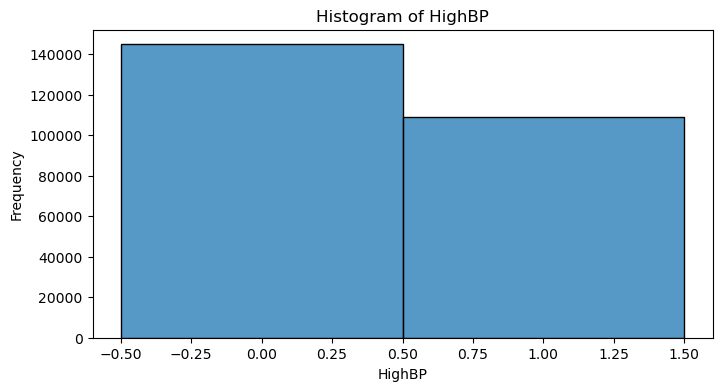

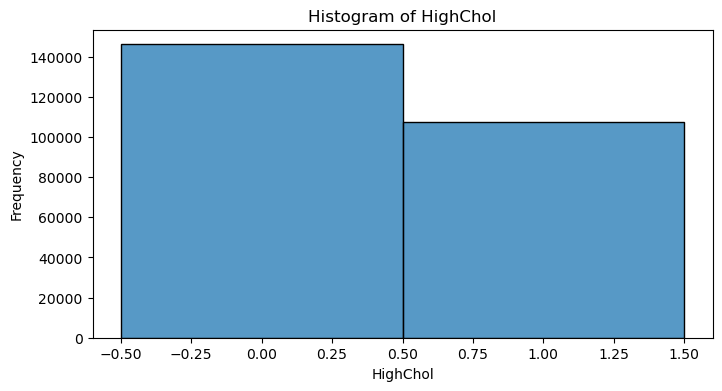

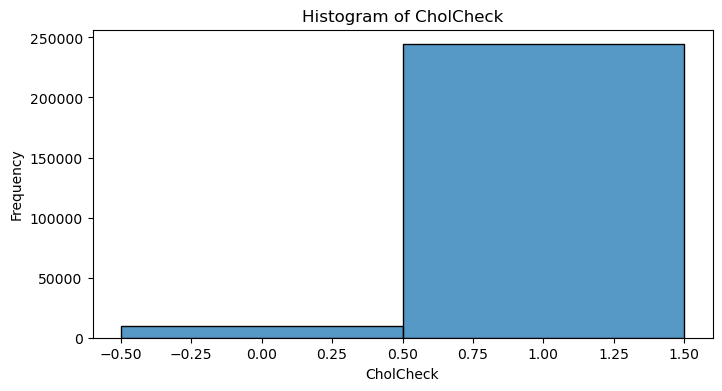

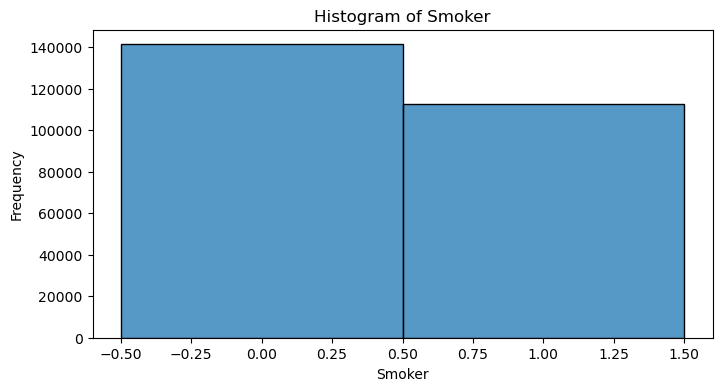

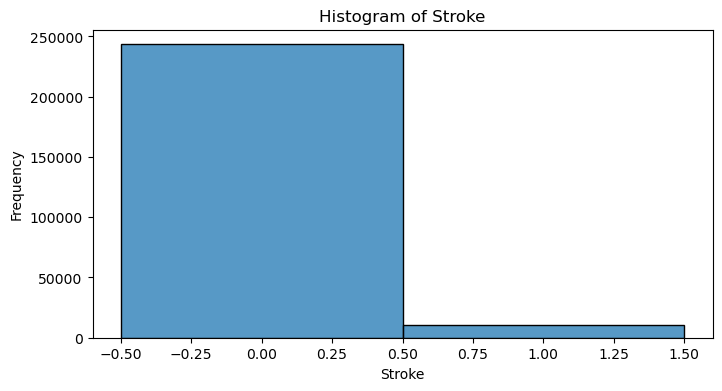

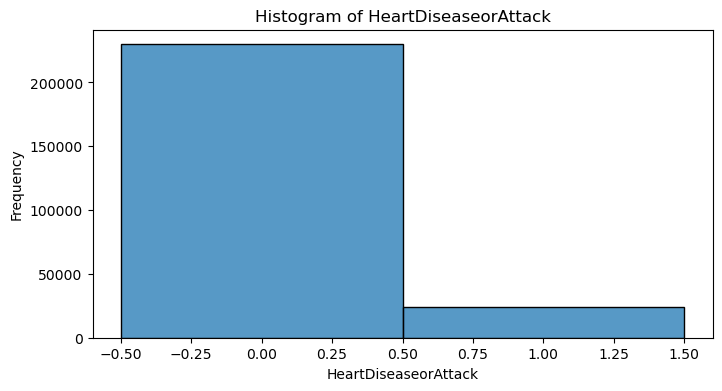

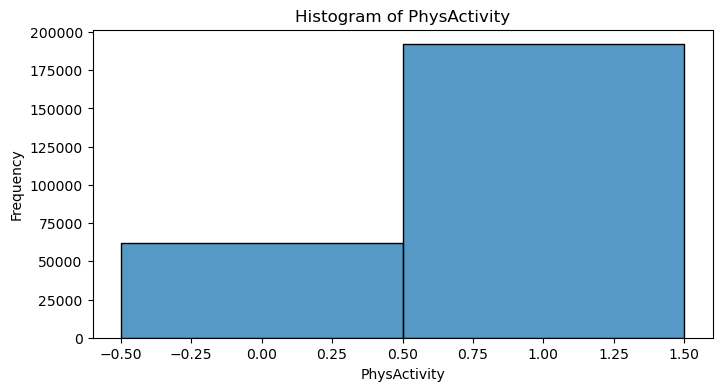

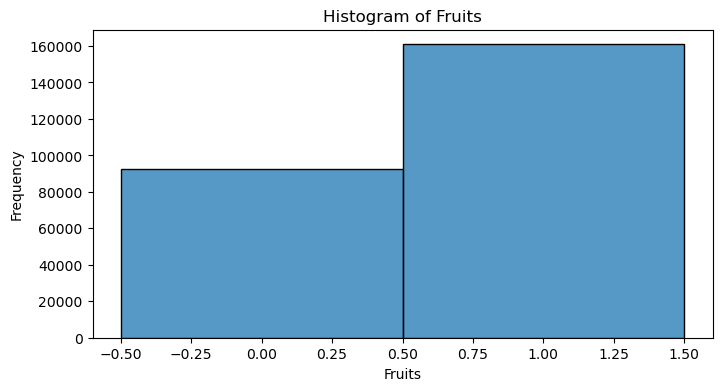

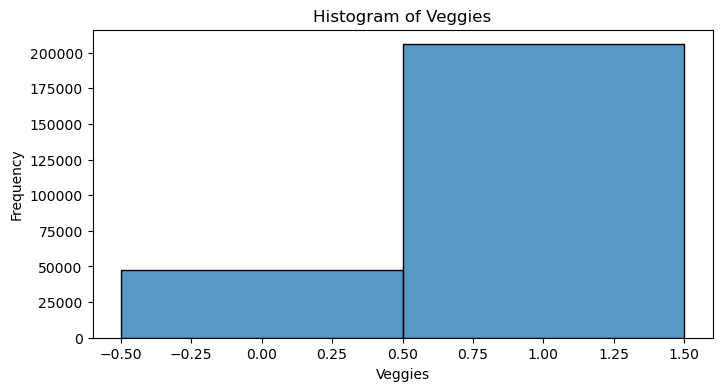

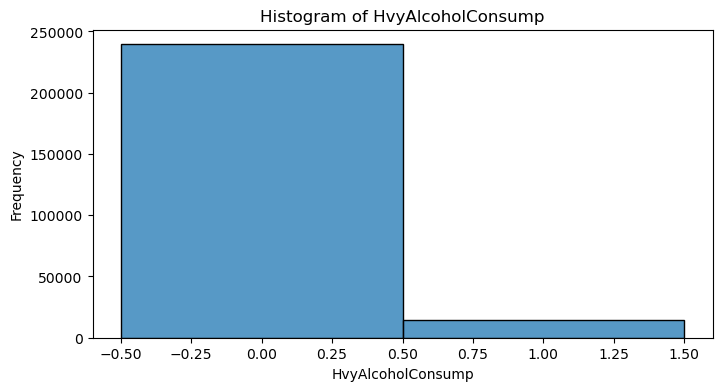

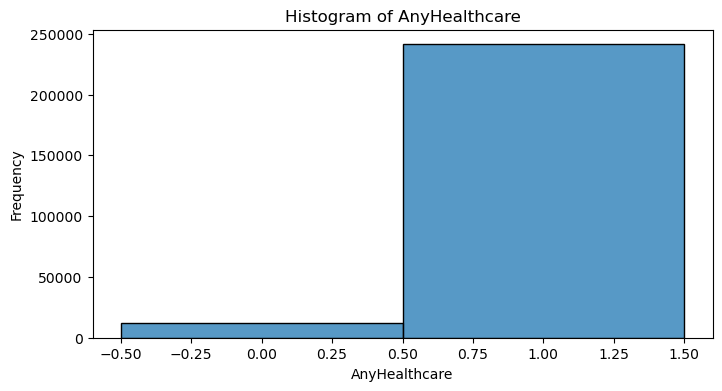

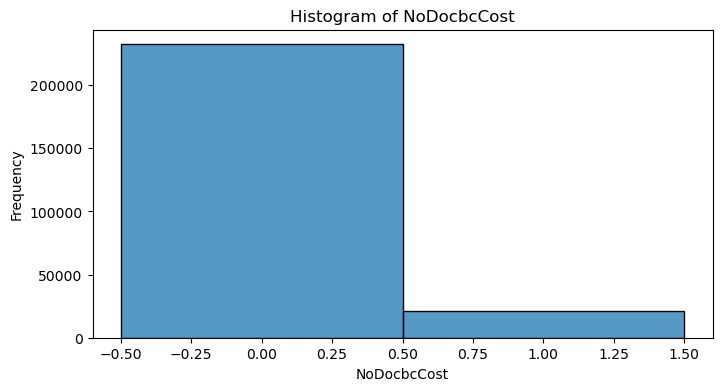

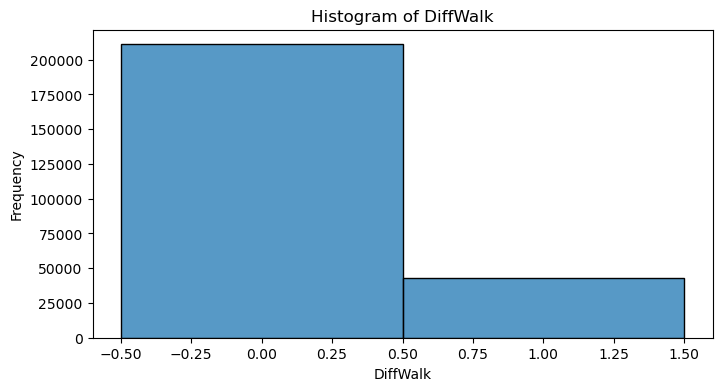

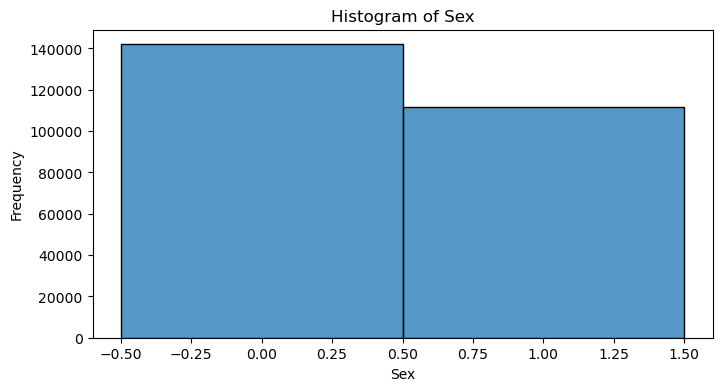

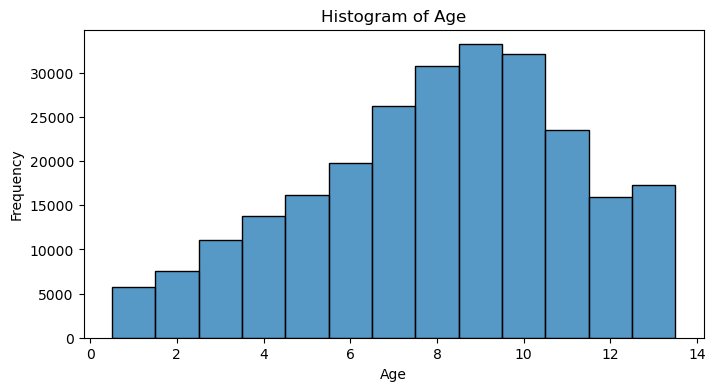

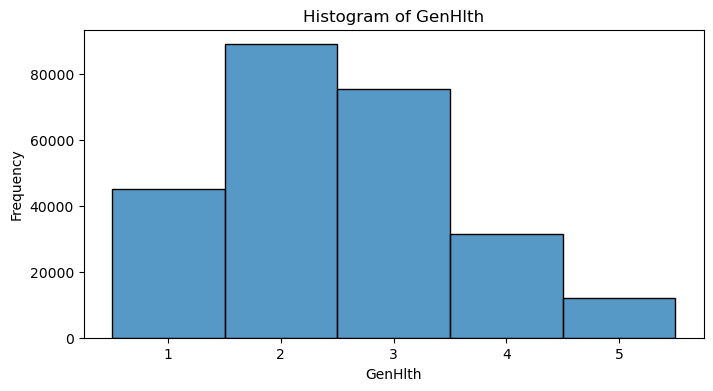

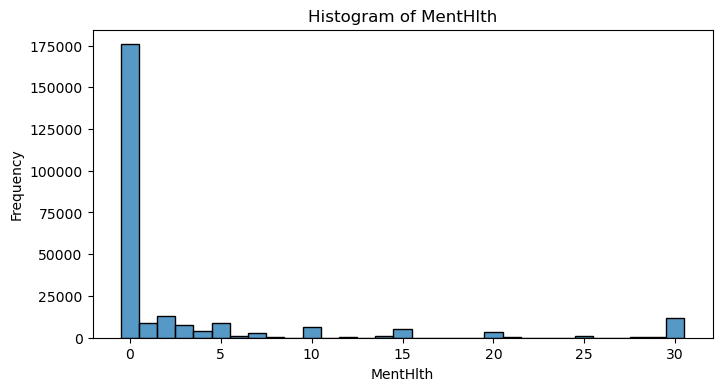

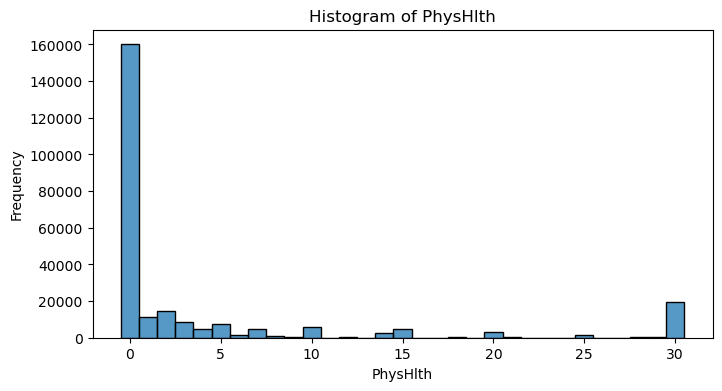

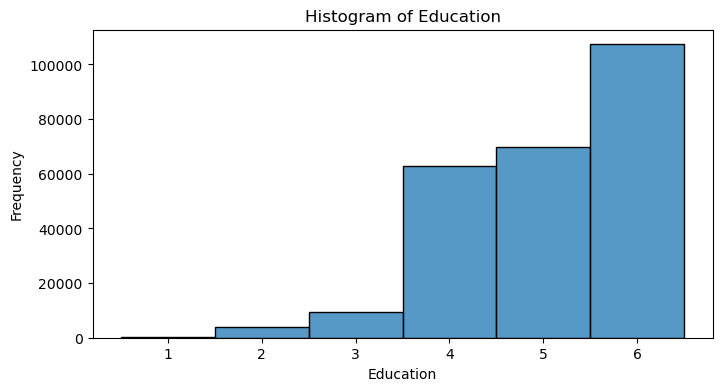

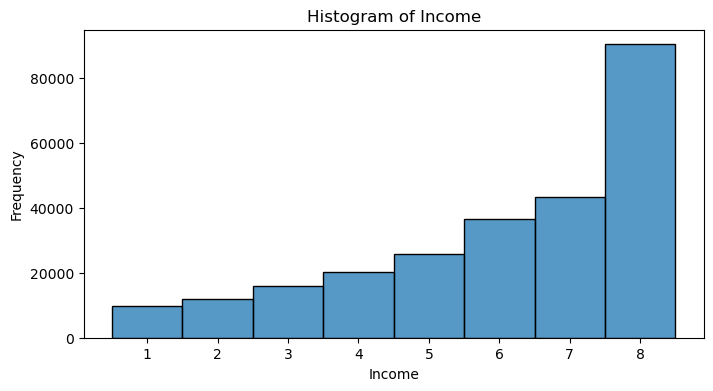

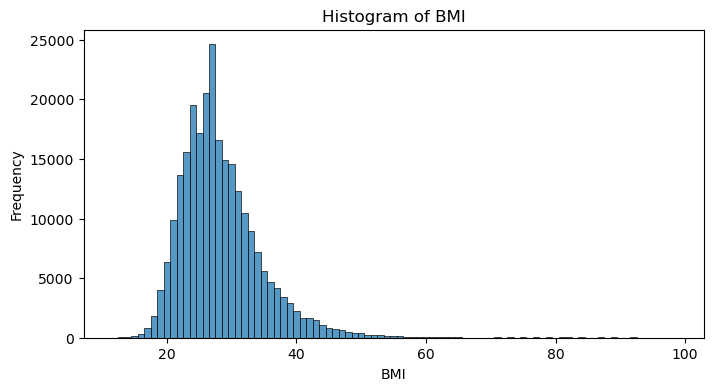

In [129]:
nominal_vars = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex', "Age"]

ordinal_vars = ['GenHlth', 'MentHlth', 'PhysHlth', 'Education', 'Income', "BMI"]

for var in nominal_vars:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_diabetes_012[var], kde=False, discrete=True)
    plt.title(f'Histogram of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.show()

for var in ordinal_vars:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_diabetes_012[var], kde=False, discrete=True)
    plt.title(f'Histogram of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.show()

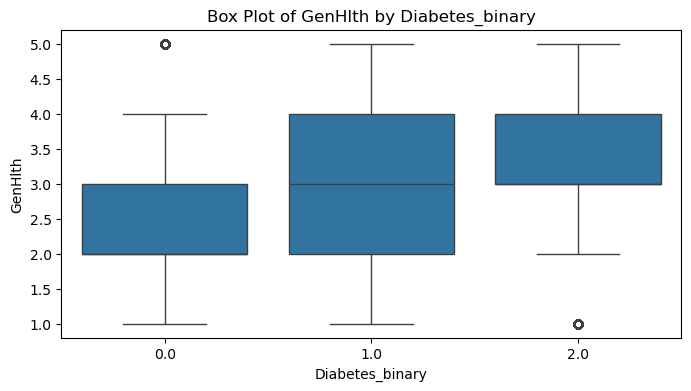

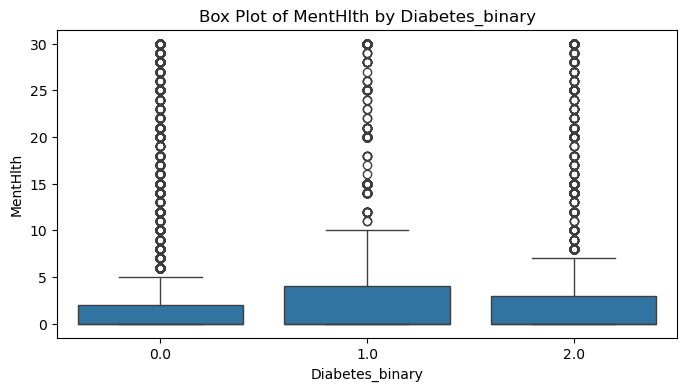

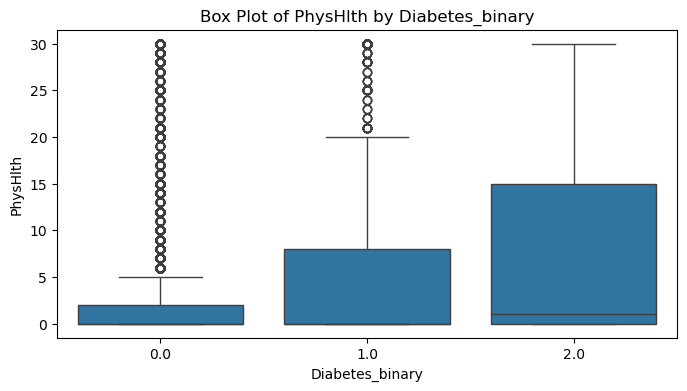

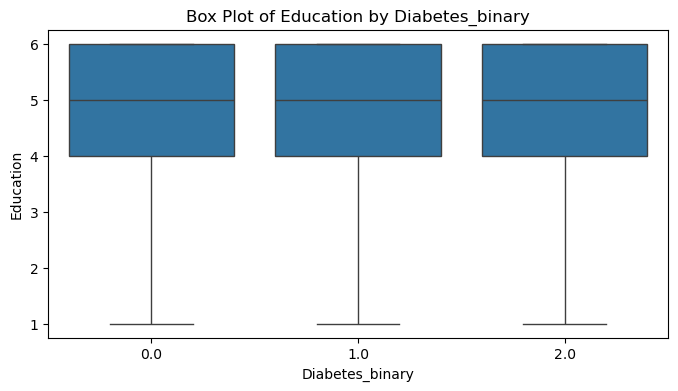

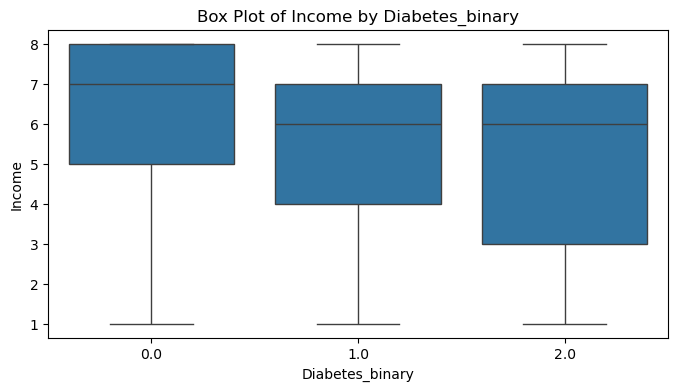

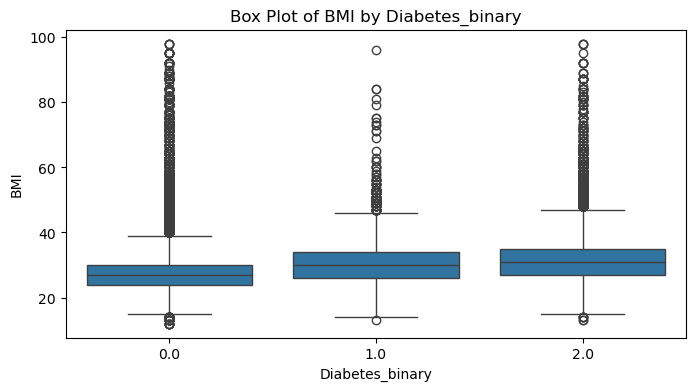

In [130]:
# Box Plots for numerical variables
for var in ordinal_vars:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='Diabetes_012', y=var, data=df_diabetes_012)
    plt.title(f'Box Plot of {var} by Diabetes_binary')
    plt.xlabel('Diabetes_binary')
    plt.ylabel(var)
    plt.show()


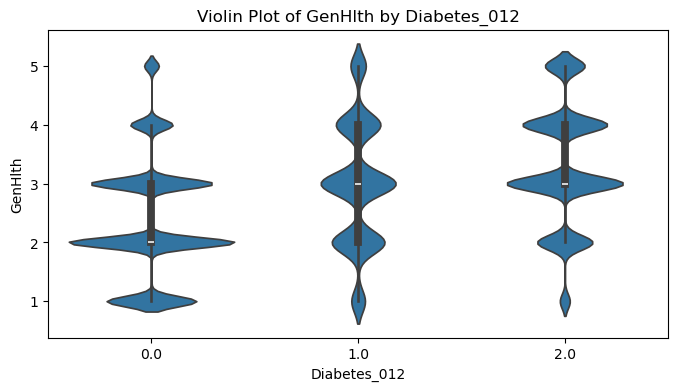

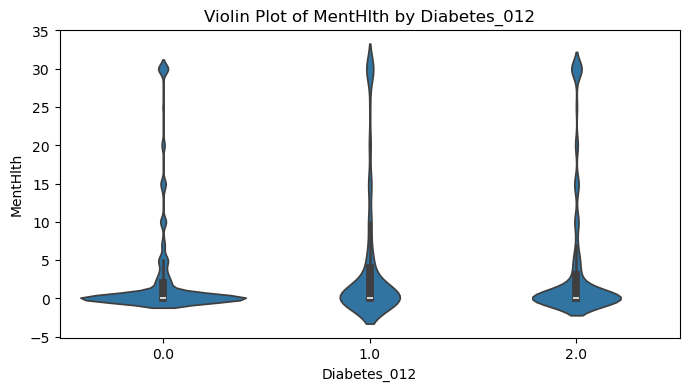

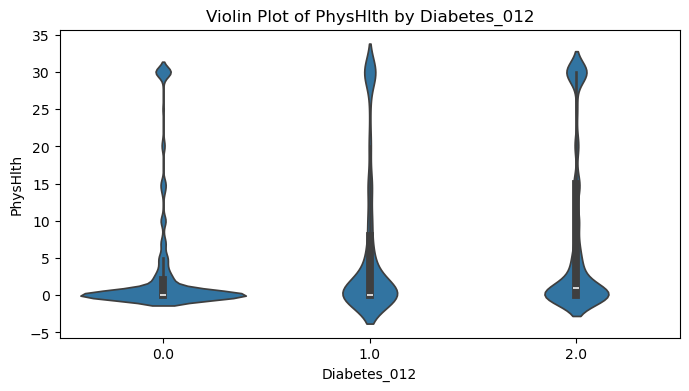

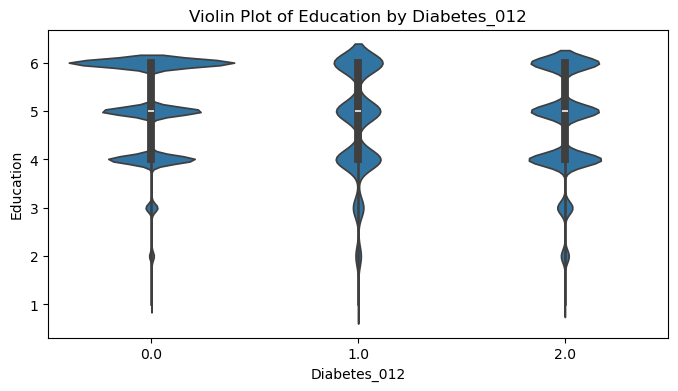

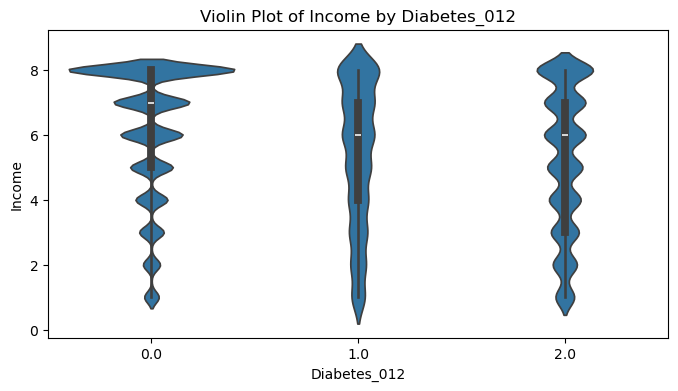

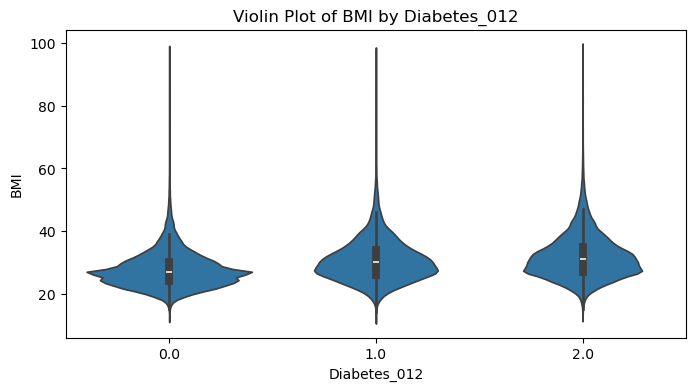

In [131]:
# Violin Plots for numerical variables
for var in ordinal_vars:
    plt.figure(figsize=(8, 4))
    sns.violinplot(x='Diabetes_012', y=var, data=df_diabetes_012)
    plt.title(f'Violin Plot of {var} by Diabetes_012')
    plt.xlabel('Diabetes_012')
    plt.ylabel(var)
    plt.show()

## Korrelationsmatrix

Die Korrelationsmatrix zeigt die Korrelationen zwischen verschiedenen Gesundheitsindikatoren im Datensatz `df_diabetes_012`. Eine Korrelation gibt an, wie stark zwei Variablen miteinander zusammenhängen. Die Werte reichen von -1 bis 1, wobei -1 eine perfekte negative Korrelation, 0 keine Korrelation und 1 eine perfekte positive Korrelation darstellt.

### Visualisierung der Korrelationsmatrix

Um die Korrelationen besser zu verstehen, haben wir eine Heatmap der Korrelationsmatrix erstellt. In dieser Heatmap sind die Korrelationen farblich dargestellt, wobei stärkere Korrelationen durch intensivere Farben hervorgehoben werden.

### Interpretation der Korrelationsmatrix

Einige wichtige Beobachtungen aus der Korrelationsmatrix sind:

- **Diabetes_012** zeigt eine moderate positive Korrelation mit **GenHlth** (0.30) und **Age** (0.19).
- **HighBP** (Bluthochdruck) korreliert stark mit **Age** (0.34) und **GenHlth** (0.30).
- **PhysActivity** (körperliche Aktivität) zeigt eine moderate negative Korrelation mit **GenHlth** (-0.27) und **DiffWalk** (-0.25).

Diese Korrelationen können Hinweise auf mögliche Zusammenhänge zwischen verschiedenen Gesundheitsindikatoren und Diabetes liefern und helfen, weitere Analysen und Hypothesen zu entwickeln.

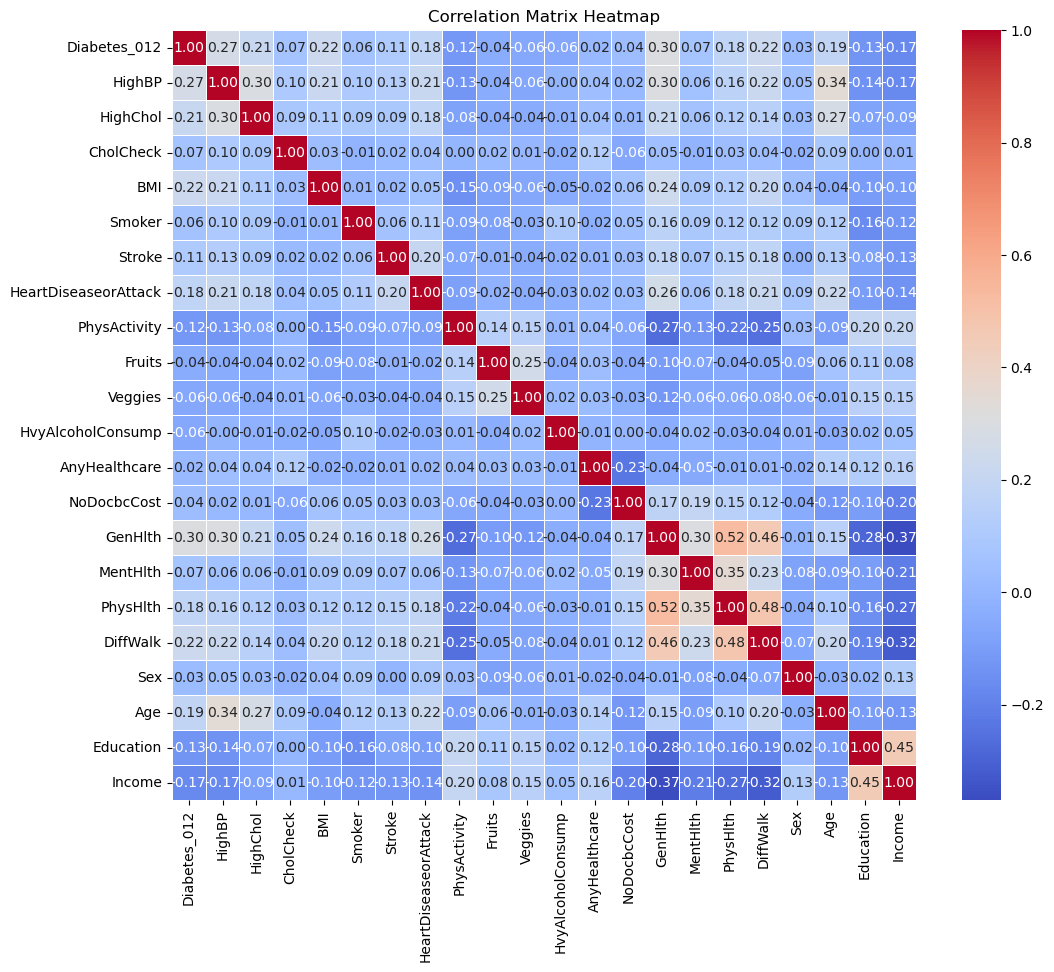

In [132]:
correlation_matrix = df_diabetes_012.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

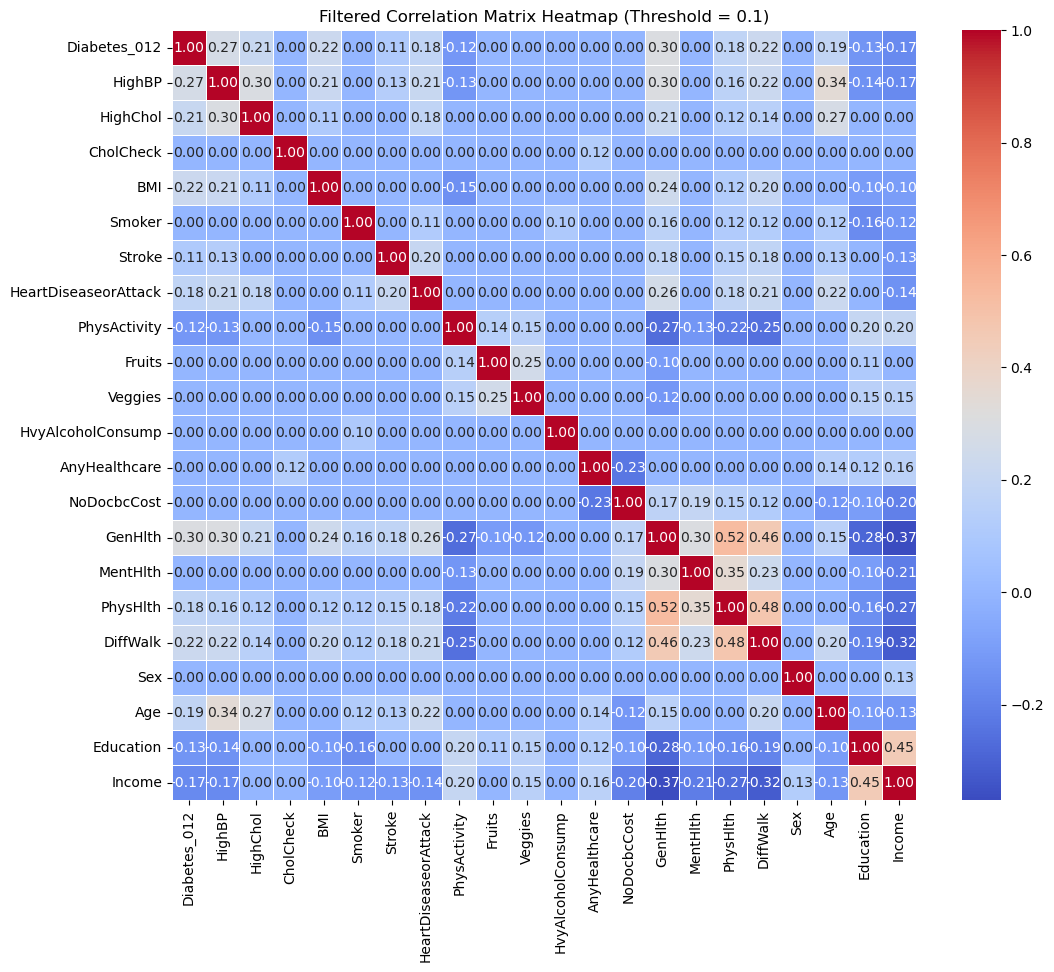

In [133]:
# Set the threshold
threshold = 0.1

# Filter the correlation matrix
filtered_correlation_matrix = correlation_matrix.copy()
filtered_correlation_matrix[abs(filtered_correlation_matrix) < threshold] = 0

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(filtered_correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Filtered Correlation Matrix Heatmap (Threshold = 0.1)')
plt.show()

# Data Preperation & Feature Enginerring


In [134]:
df_diabetes_012_cleaned = df_diabetes_012.drop(["Smoker", "Fruits", "Veggies", "HvyAlcoholConsump", "NoDocbcCost", "MentHlth", "Sex"], axis=1)
df_diabetes_binary_50_50_cleaned = df_diabetes_binary_50_50.drop(["Smoker", "Fruits", "Veggies", "HvyAlcoholConsump", "NoDocbcCost", "MentHlth", "Sex"], axis=1)

## Traning & Testdaten spliten


### df_diabetes_012

In [135]:
# Define the features and target variable
X_012 = df_diabetes_012_cleaned.drop('Diabetes_012', axis=1)
y_012 = df_diabetes_012_cleaned['Diabetes_012']

# Split the data into training and testing sets
X_train_012, X_test_012, y_train_012, y_test_012 = train_test_split(X_012, y_012, test_size=0.2, random_state=42)

display(f"Training data shape: {X_train_012.shape}")
display(f"Testing data shape: {X_test_012.shape}")

'Training data shape: (202944, 14)'

'Testing data shape: (50736, 14)'

### df_diabetes_binary_50_50

In [136]:
# Define the features and target variable
X_50_50 = df_diabetes_binary_50_50_cleaned.drop('Diabetes_binary', axis=1)
y_50_50 = df_diabetes_binary_50_50_cleaned['Diabetes_binary']

# Split the data into training and testing sets
X_train_50_50, X_test_50_50, y_train_50_50, y_test_50_50 = train_test_split(X_50_50, y_50_50, test_size=0.2, random_state=42)

display(f"Training data shape: {X_train_50_50.shape}")
display(f"Testing data shape: {X_test_50_50.shape}")

'Training data shape: (56553, 14)'

'Testing data shape: (14139, 14)'

# Modeling

## Logistic Regression

### df_diabetes_012

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.92     42795
         1.0       0.00      0.00      0.00       944
         2.0       0.52      0.17      0.26      6997

    accuracy                           0.85     50736
   macro avg       0.46      0.38      0.39     50736
weighted avg       0.80      0.85      0.81     50736

Confusion Matrix:


/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedM

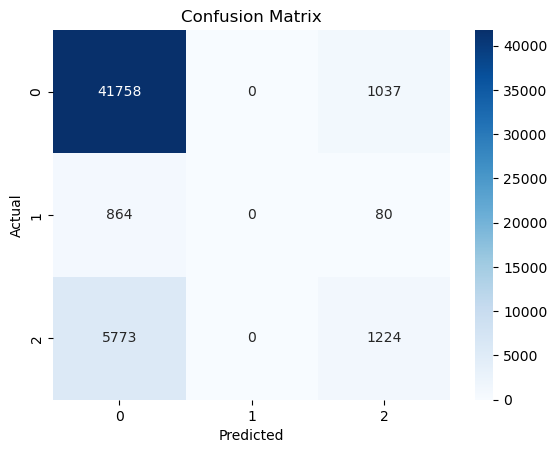

In [137]:
# Initialize the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
log_reg.fit(X_train_012, y_train_012)

# Make predictions on the test set
y_pred_log_reg_012 = log_reg.predict(X_test_012)

# Evaluate the model
# Display the classification report
print("Classification Report:")
print(classification_report(y_test_012, y_pred_log_reg_012))

# Display the confusion matrix
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test_012, y_pred_log_reg_012), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### df_diabetes_binary_50_50

Classification Report:
              precision    recall  f1-score   support

         0.0       0.76      0.73      0.74      7090
         1.0       0.74      0.76      0.75      7049

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139

Confusion Matrix:


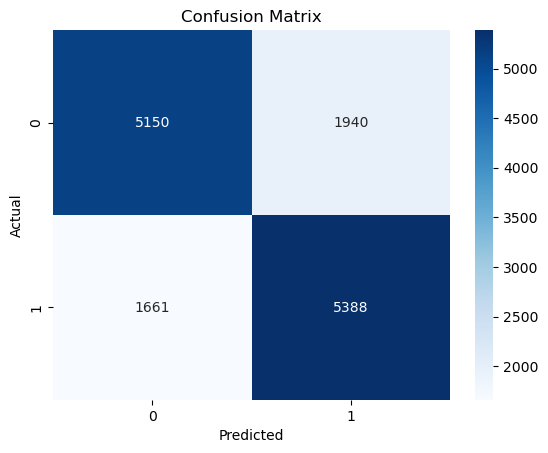

In [138]:
# Initialize the Logistic Regression model
log_reg_50_50 = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
log_reg_50_50.fit(X_train_50_50, y_train_50_50)

# Make predictions on the test set
y_pred_log_reg_50_50 = log_reg_50_50.predict(X_test_50_50)

# Evaluate the model
# Display the classification report
print("Classification Report:")
print(classification_report(y_test_50_50, y_pred_log_reg_50_50))

# Display the confusion matrix
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test_50_50, y_pred_log_reg_50_50), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## DecisionTreeClassifier

### Diabetes_012

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.88      0.88     42795
         1.0       0.04      0.05      0.05       944
         2.0       0.31      0.30      0.30      6997

    accuracy                           0.79     50736
   macro avg       0.41      0.41      0.41     50736
weighted avg       0.78      0.79      0.78     50736

Confusion Matrix:


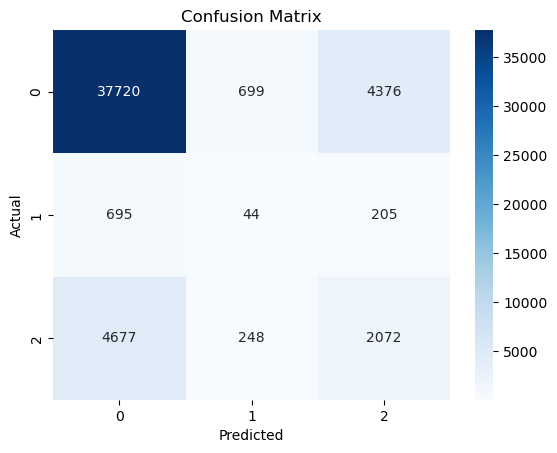

In [139]:
# Initialize the DecisionTreeClassifier
clf_012 = DecisionTreeClassifier(random_state=42)

# Train the classifier
clf_012.fit(X_train_012, y_train_012)

# Make predictions on the test set
y_pred_012 = clf_012.predict(X_test_012)

# Evaluate the model
# Display the classification report
print("Classification Report:")
print(classification_report(y_test_012, y_pred_012))

# Display the confusion matrix
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test_012, y_pred_012), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Diabetes_binary_50_50

Classification Report:
              precision    recall  f1-score   support

         0.0       0.65      0.68      0.66      7090
         1.0       0.66      0.63      0.65      7049

    accuracy                           0.65     14139
   macro avg       0.66      0.65      0.65     14139
weighted avg       0.66      0.65      0.65     14139

Confusion Matrix:


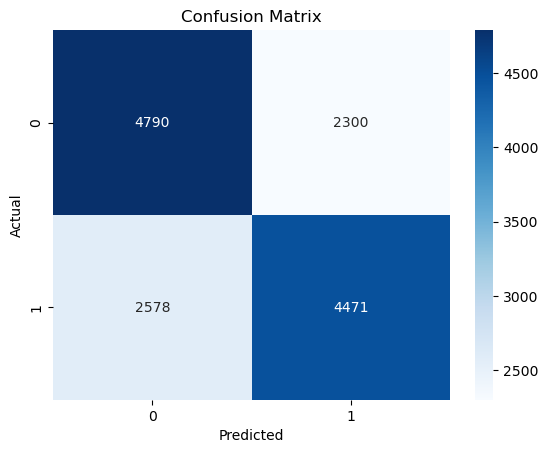

In [140]:
# Initialize the DecisionTreeClassifier
clf_50_50 = DecisionTreeClassifier(random_state=42)

# Train the classifier
clf_50_50.fit(X_train_50_50, y_train_50_50)

# Make predictions on the test set
y_pred_50_50 = clf_50_50.predict(X_test_50_50)

# Evaluate the model
# Display the classification report
print("Classification Report:")
print(classification_report(y_test_50_50, y_pred_50_50))

# Display the confusion matrix
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test_50_50, y_pred_50_50), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## KNN

### df_diabetes_012

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.95      0.91     42795
         1.0       0.02      0.00      0.00       944
         2.0       0.41      0.20      0.27      6997

    accuracy                           0.83     50736
   macro avg       0.43      0.39      0.39     50736
weighted avg       0.79      0.83      0.80     50736

Confusion Matrix:


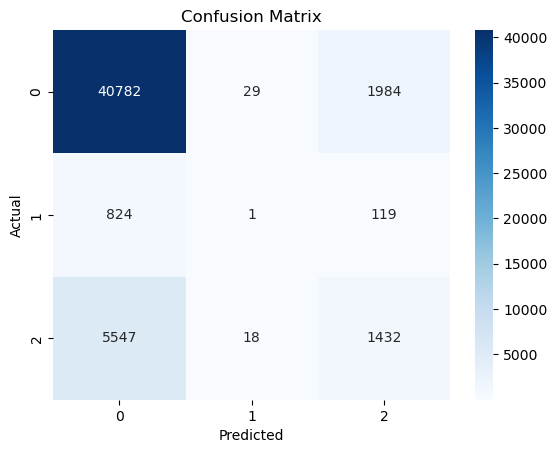

In [142]:
# Initialize the KNN model
knn_012 = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_012.fit(X_train_012, y_train_012)

# Make predictions on the test set
y_pred_knn_012 = knn_012.predict(X_test_012)

# Evaluate the model
# Display the classification report
print("Classification Report:")
print(classification_report(y_test_012, y_pred_knn_012))

# Display the confusion matrix
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test_012, y_pred_knn_012), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### diabetes_binary_50_50

Classification Report:
              precision    recall  f1-score   support

         0.0       0.72      0.68      0.70      7090
         1.0       0.70      0.73      0.71      7049

    accuracy                           0.71     14139
   macro avg       0.71      0.71      0.71     14139
weighted avg       0.71      0.71      0.71     14139

Confusion Matrix:


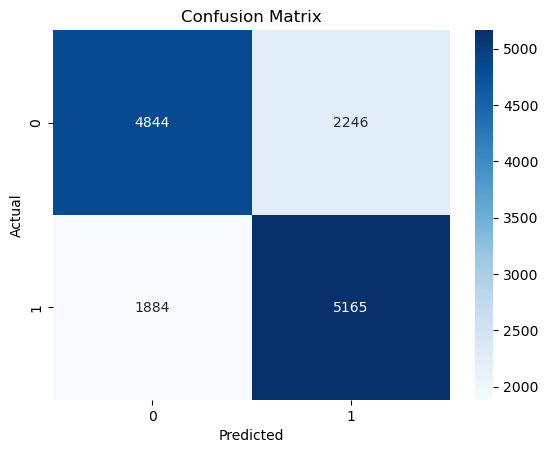

In [144]:
# Initialize the KNN model
knn_50_50 = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_50_50.fit(X_train_50_50, y_train_50_50)

# Make predictions on the test set
y_pred_knn_50_50 = knn_50_50.predict(X_test_50_50)

# Evaluate the model
# Display the classification report
print("Classification Report:")
print(classification_report(y_test_50_50, y_pred_knn_50_50))

# Display the confusion matrix
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test_50_50, y_pred_knn_50_50), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()